In [18]:
import pandas as pd
from prophet import Prophet
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [19]:
data = pd.read_csv('/Users/jon/Desktop/Ironhack/Unit 7 - Final Project/Final-Project-Ironhack/Type of analysis/Analisis temporal/merged files/csv/tesla/tesla_data.csv')

In [20]:
data

,Unnamed: 0,date,Price,revenue_musd,net_income_musd,total_assets_musd,total_liabilities_musd,share_holder_equity_musd,gdp_growth,interest_rate
0,0,2010-06-30,1.588667,28.0,-39.0,148.0,458.0,-310.0,2.91,0.18
1,1,2010-09-30,1.360667,31.0,-35.0,362.0,142.0,220.0,3.34,0.19
2,2,2010-12-31,1.775333,36.0,-51.0,386.0,179.0,207.0,2.78,0.17
3,3,2011-03-31,1.850000,49.0,-49.0,407.0,240.0,168.0,2.04,0.10
4,4,2011-06-30,1.942000,58.0,-59.0,646.0,298.0,348.0,1.74,0.07
...,...,...,...,...,...,...,...,...,...,...
56,56,2024-06-30,197.880005,25500.0,1400.0,112832.0,45641.0,67191.0,3.04,5.33
57,57,2024-09-30,261.630005,25182.0,2167.0,119852.0,49212.0,70640.0,2.72,4.83
58,58,2024-12-31,403.839996,25707.0,2131.0,122070.0,48453.0,73617.0,2.53,4.33
59,59,2025-03-31,259.160004,19335.0,409.0,125111.0,49755.0,75356.0,1.99,4.33


In [21]:
# create column assets_liabilities_ratio
data['assets_liabilities_ratio'] = data['total_assets_musd'] / data['total_liabilities_musd']

# drop columns total_assets_musd total_liabilities_musd and other unnecessary columns
data = data.drop(columns=['total_assets_musd', 'total_liabilities_musd', 'Unnamed: 0'])

In [22]:
#1)rename date to ds and Price to y for prophet

data = data.rename(columns={"date": "ds", "Price": "y"})

data["ds"]= pd.to_datetime(data["ds"], format="%Y-%m-%d")

#reorder columns
data = data[["ds", "y", "revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]]

#create backtesting data

data_bt = data.iloc[:-4]

data[40:]

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
40,2020-06-30,71.987335,6036.0,104.0,1.391230,10724.0,-7.50,0.09
41,2020-09-30,143.003326,8771.0,300.0,1.586548,16892.0,-1.41,0.09
42,2020-12-31,235.223328,10744.0,270.0,1.793692,23075.0,-1.02,0.09
43,2021-03-31,222.643326,10389.0,438.0,1.819843,23864.0,1.76,0.07
44,2021-06-30,226.566666,11958.0,1142.0,1.869293,25645.0,12.24,0.10
45,2021-09-30,258.493347,13757.0,1618.0,1.931341,27889.0,4.98,0.08
46,2021-12-31,352.260010,17719.0,2326.0,1.996754,31015.0,5.72,0.08
47,2022-03-31,359.200012,18756.0,3313.0,2.124023,34947.0,4.01,0.33
48,2022-06-30,224.473328,16934.0,2259.0,2.190593,37237.0,2.48,1.68
49,2022-09-30,265.250000,21454.0,3292.0,2.206980,40703.0,2.30,3.08


In [23]:
#2) Add a future base scenario so Proheet can make predictions

# ================== CONFIG ==================
FUTURE_PERIODS = 6    # nº de trimestres a predecir
FREQ = "Q"            # frecuencia trimestral
REG_COLS = ["revenue_musd", "net_income_musd", "assets_liabilities_ratio", "share_holder_equity_musd", "gdp_growth", "interest_rate"]

# ================== PREP ====================
df = data.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df["ds"] = pd.to_datetime(df["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df["gdp_growth"].dtype == "object":
    df["gdp_growth"] = (
        df["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df[REG_COLS] = df[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates[col] = df[col].pct_change().mean(skipna=True)

growth_rates["gdp_growth"]=df["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates["interest_rate"]=df["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last = df.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future = pd.DataFrame({"ds": future_dates})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr = 0.0 if np.isnan(growth_rates[col]) else growth_rates[col]
    future[col] = [last[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future["assets_liabilities_ratio"] = last["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future["gdp_growth"] = last["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future["interest_rate"] = last["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist = df[["ds", "y"] + REG_COLS].copy()
future_full = pd.concat([hist, future], ignore_index=True)


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10820/1567433887.py:42: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates = pd.date_range(start=df["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [24]:
#2) Replicate the same for backtesting data

# ================== PREP ====================
df_bt = data_bt.copy()
#df = df.rename(columns={"DS": "ds"})   # Prophet requiere columnas: ds (datetime), y (target)
df_bt["ds"] = pd.to_datetime(df_bt["ds"], errors="coerce")

# Asegura que los regresores existan (si falta alguno, lo creamos como NaN)
for c in REG_COLS:
    if c not in df.columns:
        df_bt[c] = np.nan

# Convierte gdp_growth a numérico si venía como texto/%
if df_bt["gdp_growth"].dtype == "object":
    df_bt["gdp_growth"] = (
        df_bt["gdp_growth"].astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False)
        .replace({"": np.nan}).astype(float)
    )

# Rellena huecos internos con forward-fill (opcional pero útil para entrenar)
df_bt[REG_COLS] = df_bt[REG_COLS].ffill()

# ================== ESCENARIO FUTURO ==================
# Calcula crecimiento medio trimestral para flows/equity
growth_rates_bt = {}
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:  #Calculate growth rates and append to dictionary
    growth_rates_bt[col] = df_bt[col].pct_change().mean(skipna=True)

growth_rates_bt["gdp_growth"]=df_bt["gdp_growth"].mean() #Cause gdp_growth is already a growth rate just calculate the mean
growth_rates_bt["interest_rate"]=df_bt["interest_rate"].mean() #Cause interest_rate is already a rate just calculate the mean


# Último punto observado
last_bt = df_bt.sort_values("ds").iloc[-1]

# Fechas futuras
future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]
future_bt = pd.DataFrame({"ds": future_dates_bt})

# Proyecta regresores (escenario baseline)
for col in ["revenue_musd", "net_income_musd", "share_holder_equity_musd"]:
    gr_bt = 0.0 if np.isnan(growth_rates_bt[col]) else growth_rates_bt[col]
    future_bt[col] = [last_bt[col] * (1 + gr) ** i for i in range(1, FUTURE_PERIODS+1)]

# Mantén constantes estos regresores (o pon tu propio escenario)
future_bt["assets_liabilities_ratio"] = last_bt["assets_liabilities_ratio"]
# gdp_growth: mantener último valor (o define tu propio escenario macro)
future_bt["gdp_growth"] = last_bt["gdp_growth"]
# interest_rate: mantener último valor (o define tu propio escenario macro)
future_bt["interest_rate"] = last_bt["interest_rate"]

# Combina histórico (con y) y futuro (sin y)
hist_bt = df_bt[["ds", "y"] + REG_COLS].copy()
future_full_bt = pd.concat([hist_bt, future_bt], ignore_index=True)

/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10820/1325257280.py:37: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  future_dates_bt = pd.date_range(start=df_bt["ds"].max(), periods=FUTURE_PERIODS+1, freq=FREQ)[1:]


In [25]:
growth_rates_bt

{'revenue_musd': np.float64(0.21139653031863667),
 'net_income_musd': np.float64(-0.051457256825112006),
 'share_holder_equity_musd': np.float64(0.005337474836982318),
 'gdp_growth': np.float64(2.4173684210526316),
 'interest_rate': np.float64(1.1771929824561405)}

In [26]:
#3) Initializa model and an train it

m=Prophet()

for col in REG_COLS:
    m.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df = future_full.dropna(subset=["y"]).copy()
m.fit(train_df)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df = future_full[["ds"] + REG_COLS].copy()
forecast = m.predict(predict_df)

#6) Plot the results. Merge forecast with original data to compare
out = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out.tail(12))



14:55:41 - cmdstanpy - INFO - Chain [1] start processing
14:55:42 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
55 2024-03-31  189.634891  162.320293  221.698250  175.789993
56 2024-06-30  244.999571  214.286548  273.738268  197.880005
57 2024-09-30  282.227795  253.851253  312.861868  261.630005
58 2024-12-31  356.662552  325.393667  386.351481  403.839996
59 2025-03-31  269.576874  239.567618  301.597357  259.160004
60 2025-06-30  307.013409  275.422440  338.920968  317.660004
61 2025-09-30  362.532542  332.691902  393.133758         NaN
62 2025-12-31  426.918729  395.913824  456.614510         NaN
63 2026-03-31  496.883356  467.937083  527.537694         NaN
64 2026-06-30  571.531276  541.898141  600.533008         NaN
65 2026-09-30  671.117825  639.245404  700.159544         NaN
66 2026-12-31  772.067211  742.572384  802.026755         NaN


In [27]:
#3) Replicate the same for backtesting data

m_bt=Prophet()

for col in REG_COLS:
    m_bt.add_regressor(col)

#4) Fit and train with only historical data (with y)
train_df_bt = future_full_bt.dropna(subset=["y"]).copy()
m_bt.fit(train_df_bt)
                       

#5) Make predictions for the full dataset (historical + future)
predict_df_bt = future_full_bt[["ds"] + REG_COLS].copy()
forecast_bt = m_bt.predict(predict_df_bt)

#6) Plot the results. Merge forecast with original data to compare
out_bt = forecast_bt[["ds", "yhat", "yhat_lower", "yhat_upper"]].merge(
    df_bt[["ds","y"]], on="ds", how="left"
).sort_values("ds")

print(out_bt.tail(12))

14:55:42 - cmdstanpy - INFO - Chain [1] start processing
14:55:42 - cmdstanpy - INFO - Chain [1] done processing


           ds        yhat  yhat_lower  yhat_upper           y
51 2023-03-31  216.524657  186.057846  246.910836  207.460007
52 2023-06-30  229.807320  201.935691  257.922945  261.769989
53 2023-09-30  205.121336  176.693091  233.357820  250.220001
54 2023-12-31  231.156102  202.025829  262.108815  248.479996
55 2024-03-31  181.063225  151.968748  210.199359  175.789993
56 2024-06-30  235.946630  206.553188  266.055863  197.880005
57 2024-09-30  249.880959  220.542267  279.762113         NaN
58 2024-12-31  272.962974  244.121841  302.009535         NaN
59 2025-03-31  263.194129  233.595635  291.065484         NaN
60 2025-06-30  262.025907  232.719953  294.878989         NaN
61 2025-09-30  274.691530  244.897456  304.239738         NaN
62 2025-12-31  279.086970  250.280726  306.777030         NaN


In [28]:
#4) Merge prediction with actual y

# Keep all rows (historical + future)
results = forecast[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results["is_future"] = results["y"].isna()

# Compute metrics only on historical rows
mask = ~results["is_future"]
mae = mean_absolute_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
rmse = mean_squared_error(results.loc[mask,"y"], results.loc[mask,"yhat"])
r2   = r2_score(results.loc[mask,"y"], results.loc[mask,"yhat"])

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

# Show last 12 rows (will include future with y = NaN)
print(results.tail(12))

MAE: 17.934274151732108
RMSE: 562.0956851559771
R²: 0.9592951462483833
           ds        yhat  yhat_lower  yhat_upper           y  is_future
55 2024-03-31  189.634891  162.320293  221.698250  175.789993      False
56 2024-06-30  244.999571  214.286548  273.738268  197.880005      False
57 2024-09-30  282.227795  253.851253  312.861868  261.630005      False
58 2024-12-31  356.662552  325.393667  386.351481  403.839996      False
59 2025-03-31  269.576874  239.567618  301.597357  259.160004      False
60 2025-06-30  307.013409  275.422440  338.920968  317.660004      False
61 2025-09-30  362.532542  332.691902  393.133758         NaN       True
62 2025-12-31  426.918729  395.913824  456.614510         NaN       True
63 2026-03-31  496.883356  467.937083  527.537694         NaN       True
64 2026-06-30  571.531276  541.898141  600.533008         NaN       True
65 2026-09-30  671.117825  639.245404  700.159544         NaN       True
66 2026-12-31  772.067211  742.572384  802.026755    

In [29]:
#4) Replicate the same for backtesting data

# Keep all rows (historical + future)
results_bt = forecast_bt[["ds","yhat","yhat_lower","yhat_upper"]].merge(
    data_bt.rename(columns={"DS":"ds"})[["ds","y"]],
    on="ds", how="left"
)

# Flag which rows are future
results_bt["is_future"] = results_bt["y"].isna()

# Compute metrics only on historical rows
mask_bt = ~results_bt["is_future"]
mae_bt = mean_absolute_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
rmse_bt = mean_squared_error(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])
r2_bt   = r2_score(results_bt.loc[mask_bt,"y"], results_bt.loc[mask_bt,"yhat"])

print("MAE:", mae_bt)
print("RMSE:", rmse_bt)
print("R²:", r2_bt)

# Show last 12 rows (will include future with y = NaN)
print(results_bt.tail(12))

MAE: 17.079719533982757
RMSE: 535.5519580005135
R²: 0.9510065752476566
           ds        yhat  yhat_lower  yhat_upper           y  is_future
51 2023-03-31  216.524657  186.057846  246.910836  207.460007      False
52 2023-06-30  229.807320  201.935691  257.922945  261.769989      False
53 2023-09-30  205.121336  176.693091  233.357820  250.220001      False
54 2023-12-31  231.156102  202.025829  262.108815  248.479996      False
55 2024-03-31  181.063225  151.968748  210.199359  175.789993      False
56 2024-06-30  235.946630  206.553188  266.055863  197.880005      False
57 2024-09-30  249.880959  220.542267  279.762113         NaN       True
58 2024-12-31  272.962974  244.121841  302.009535         NaN       True
59 2025-03-31  263.194129  233.595635  291.065484         NaN       True
60 2025-06-30  262.025907  232.719953  294.878989         NaN       True
61 2025-09-30  274.691530  244.897456  304.239738         NaN       True
62 2025-12-31  279.086970  250.280726  306.777030    

In [36]:
data

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
0,2010-06-30,1.588667,28.0,-39.0,0.323144,-310.0,2.91,0.18
1,2010-09-30,1.360667,31.0,-35.0,2.549296,220.0,3.34,0.19
2,2010-12-31,1.775333,36.0,-51.0,2.156425,207.0,2.78,0.17
3,2011-03-31,1.850000,49.0,-49.0,1.695833,168.0,2.04,0.10
4,2011-06-30,1.942000,58.0,-59.0,2.167785,348.0,1.74,0.07
...,...,...,...,...,...,...,...,...
56,2024-06-30,197.880005,25500.0,1400.0,2.472163,67191.0,3.04,5.33
57,2024-09-30,261.630005,25182.0,2167.0,2.435422,70640.0,2.72,4.83
58,2024-12-31,403.839996,25707.0,2131.0,2.519349,73617.0,2.53,4.33
59,2025-03-31,259.160004,19335.0,409.0,2.514541,75356.0,1.99,4.33


In [ ]:
#5) Compare the actuall y with the yhat prediction for the backtesting period
comparison = data[["ds", "y"]]
comparison_bt = results_bt[["ds", "yhat"]]
comparison = comparison.merge(comparison_bt, on="ds", how="inner")
comparison["absolute error"] = (comparison["y"] - comparison["yhat"]).abs()
comparison["relative error"] = ((comparison["absolute error"] / comparison["y"])*100).round(1).astype(str)+"%"
print(comparison.tail(12))

           ds           y        yhat  absolute error relative error
49 2022-09-30  265.250000  244.203801       21.046199           7.9%
50 2022-12-31  123.180000  215.543198       92.363197          75.0%
51 2023-03-31  207.460007  216.524657        9.064650           4.4%
52 2023-06-30  261.769989  229.807320       31.962669          12.2%
53 2023-09-30  250.220001  205.121336       45.098665          18.0%
54 2023-12-31  248.479996  231.156102       17.323894           7.0%
55 2024-03-31  175.789993  181.063225        5.273232           3.0%
56 2024-06-30  197.880005  235.946630       38.066625          19.2%
57 2024-09-30  261.630005  249.880959       11.749046           4.5%
58 2024-12-31  403.839996  272.962974      130.877022          32.4%
59 2025-03-31  259.160004  263.194129        4.034125           1.6%
60 2025-06-30  317.660004  262.025907       55.634097          17.5%


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10820/3947255231.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl.show()


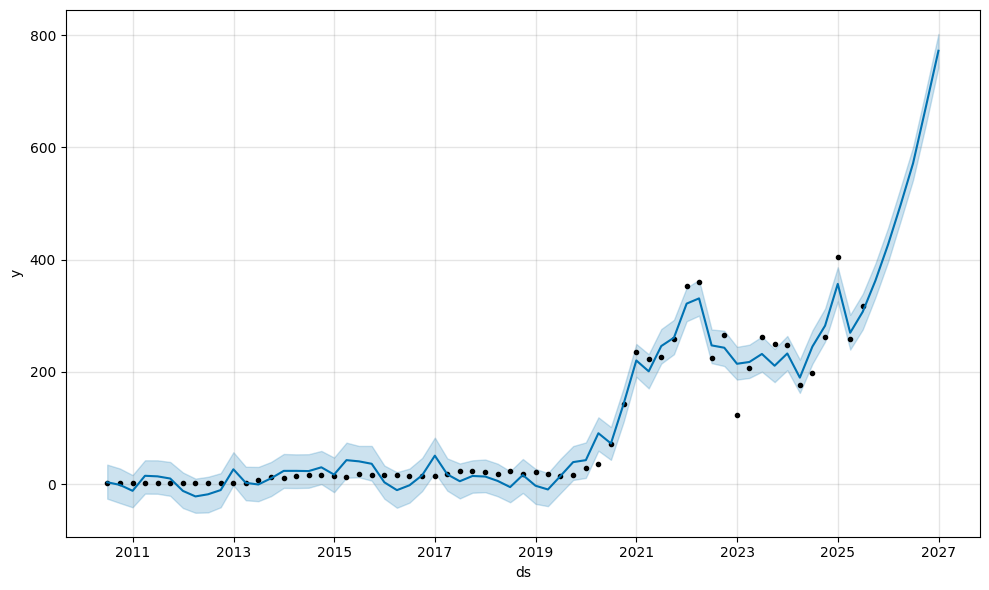

In [31]:
#5) Plot the results

figl = m.plot(forecast)
figl.show()

In [32]:
correlations = data.corr()
correlations

,ds,y,revenue_musd,net_income_musd,assets_liabilities_ratio,share_holder_equity_musd,gdp_growth,interest_rate
ds,1.000000,0.818072,0.901363,0.606545,0.616730,0.853719,0.069048,0.743550
y,0.818072,1.000000,0.893208,0.717973,0.761304,0.871889,0.193317,0.557192
revenue_musd,0.901363,0.893208,1.000000,0.797870,0.799812,0.955669,0.132494,0.836047
net_income_musd,0.606545,0.717973,0.797870,1.000000,0.664903,0.712110,0.167258,0.597044
assets_liabilities_ratio,0.616730,0.761304,0.799812,0.664903,1.000000,0.825935,0.114217,0.643634
share_holder_equity_musd,0.853719,0.871889,0.955669,0.712110,0.825935,1.000000,0.104535,0.841333
gdp_growth,0.069048,0.193317,0.132494,0.167258,0.114217,0.104535,1.000000,0.062314
interest_rate,0.743550,0.557192,0.836047,0.597044,0.643634,0.841333,0.062314,1.000000


/var/folders/_2/ksgd3nl52j9g0sxwpjjd1bgh0000gn/T/ipykernel_10820/89357559.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figl_bt.show()


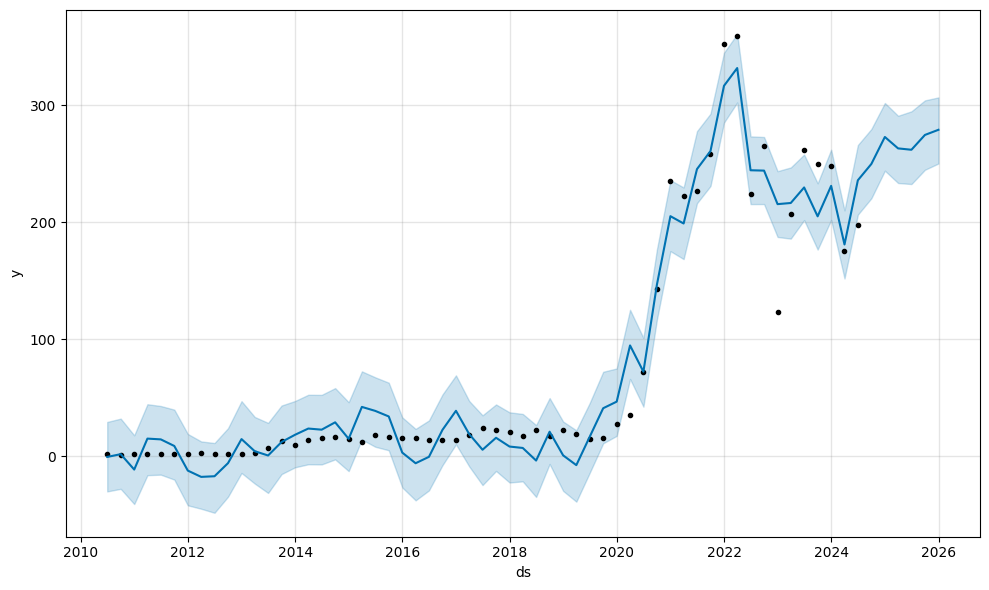

In [33]:
# 5) Plot the results for backtesting data

figl_bt = m_bt.plot(forecast_bt)
figl_bt.show()

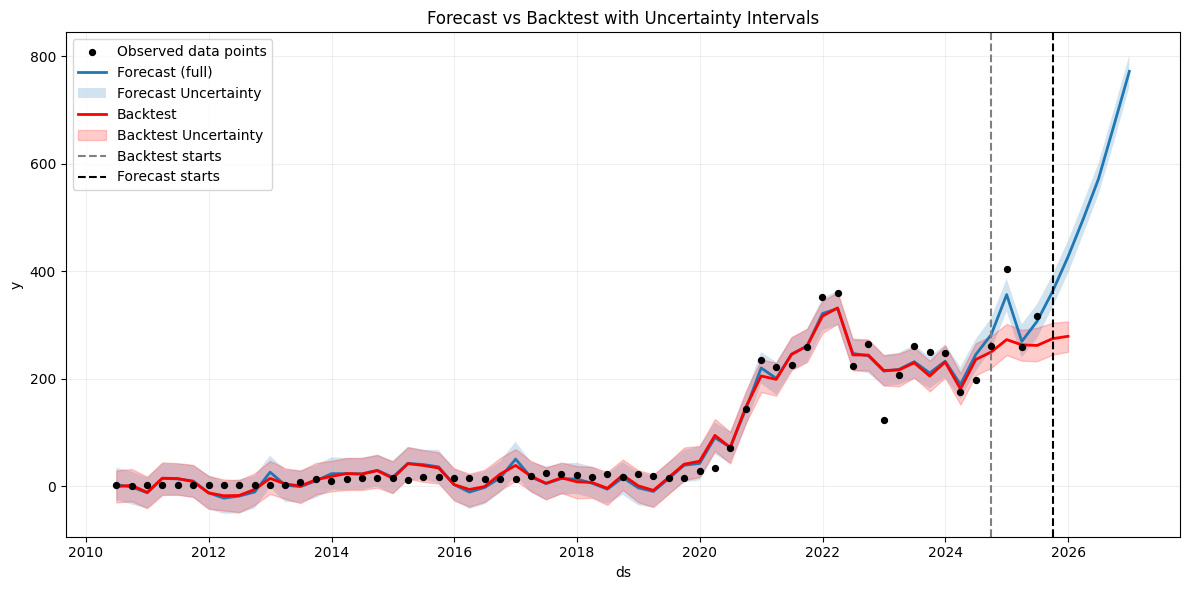

In [34]:
#6) Plot the results together

# --- Ensure datetime dtype
results['ds'] = pd.to_datetime(results['ds'])
results_bt['ds'] = pd.to_datetime(results_bt['ds'])

# --- Find split dates
bt_split   = results_bt.loc[results_bt['is_future'], 'ds'].min()   # ~2024-09-30
full_split = results.loc[results['is_future'], 'ds'].min()         # ~2025-09-30

fig, ax = plt.subplots(figsize=(12,6))

# Actuals (dots) from full dataset
mask_actual = ~results['is_future']
ax.scatter(results.loc[mask_actual, 'ds'],
           results.loc[mask_actual, 'y'],
           s=18, label='Observed data points', zorder=3, color='k')

# Forecast (full) line + CI
ax.plot(results['ds'], results['yhat'], label='Forecast (full)', linewidth=2)
ax.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                alpha=0.2, label='Forecast Uncertainty')

# Backtest line + CI
ax.plot(results_bt['ds'], results_bt['yhat'], label='Backtest', linewidth=2, color='red')
ax.fill_between(results_bt['ds'], results_bt['yhat_lower'], results_bt['yhat_upper'],
                alpha=0.2, label='Backtest Uncertainty', color='red')

# --- Vertical split lines
if pd.notna(bt_split):
    ax.axvline(bt_split, linestyle='--', linewidth=1.5, color='gray')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='gray', label='Backtest starts')

if pd.notna(full_split):
    ax.axvline(full_split, linestyle='--', linewidth=1.5, color='black')
    # Dummy handle just for legend
    ax.plot([], [], linestyle='--', linewidth=1.5, color='black', label='Forecast starts')

# Cosmetics
ax.set_title('Forecast vs Backtest with Uncertainty Intervals')
ax.set_xlabel('ds'); ax.set_ylabel('y')
# Deduplicate legend labels
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), loc='upper left')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()